In [2]:
import pandas as pd

df = pd.read_csv("netflix_titles.csv")

print(df.head())
print(df.info())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [3]:
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [11]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Not Available')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df['duration'] = df['duration'].fillna('Unknown')
df['date_added'] = df['date_added'].fillna('Unknown')

In [12]:
print(df.isnull().sum())

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [13]:
df.drop_duplicates(inplace=True)

print("Duplicates:", df.duplicated().sum())

Duplicates: 0


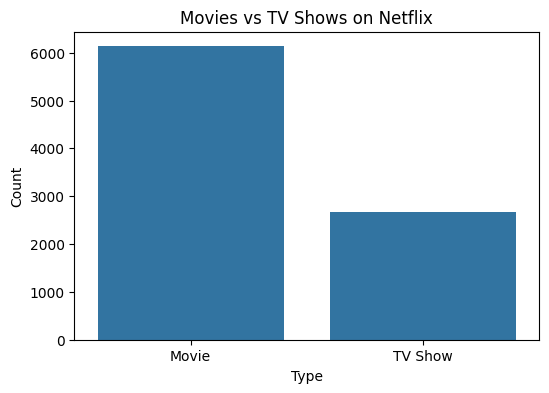

In [14]:
#1. Movies vs TV Shows
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df)

plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')

plt.show()

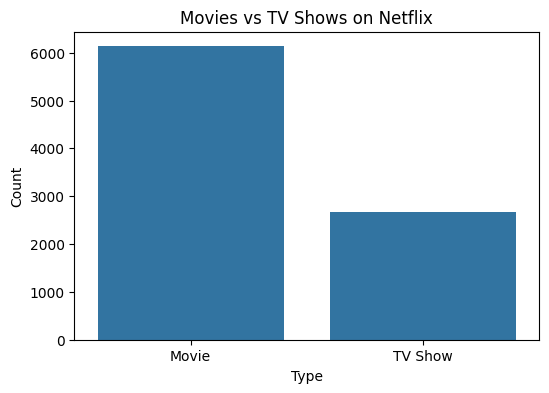

In [15]:
#2.Top 10 Countries Producing Content
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df)

plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')

plt.show()

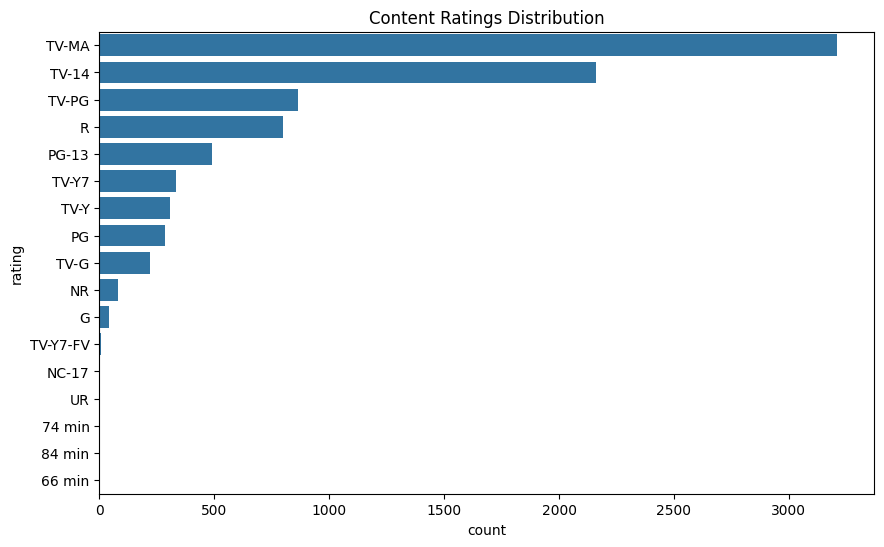

In [16]:
#3.Most Common Ratings
plt.figure(figsize=(10,6))

sns.countplot(
    y='rating',
    data=df,
    order=df['rating'].value_counts().index
)

plt.title('Content Ratings Distribution')

plt.show()

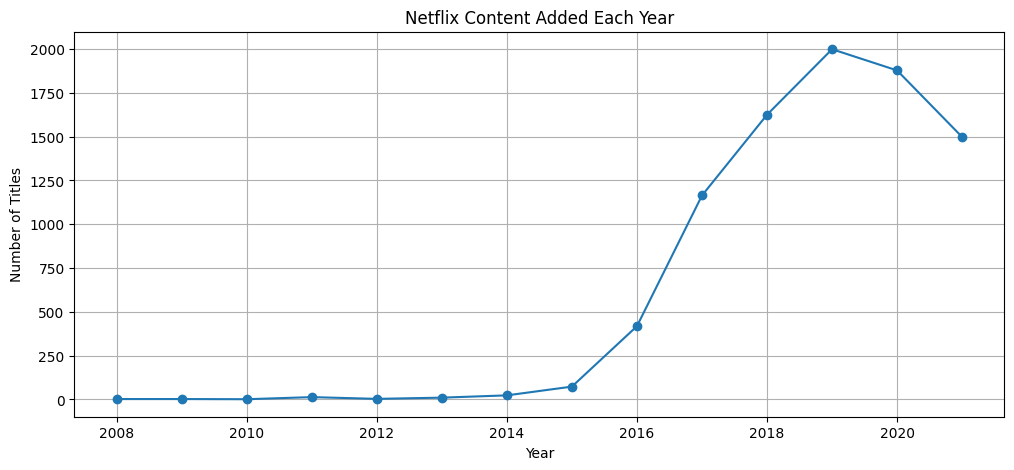

In [17]:
#4.Netflix Growth Over Time
df['date_added'] = pd.to_datetime(
    df['date_added'],
    errors='coerce'
)

df['year_added'] = df['date_added'].dt.year

yearly = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(12,5))

yearly.plot(
    kind='line',
    marker='o'
)

plt.title('Netflix Content Added Each Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')

plt.grid(True)

plt.show()

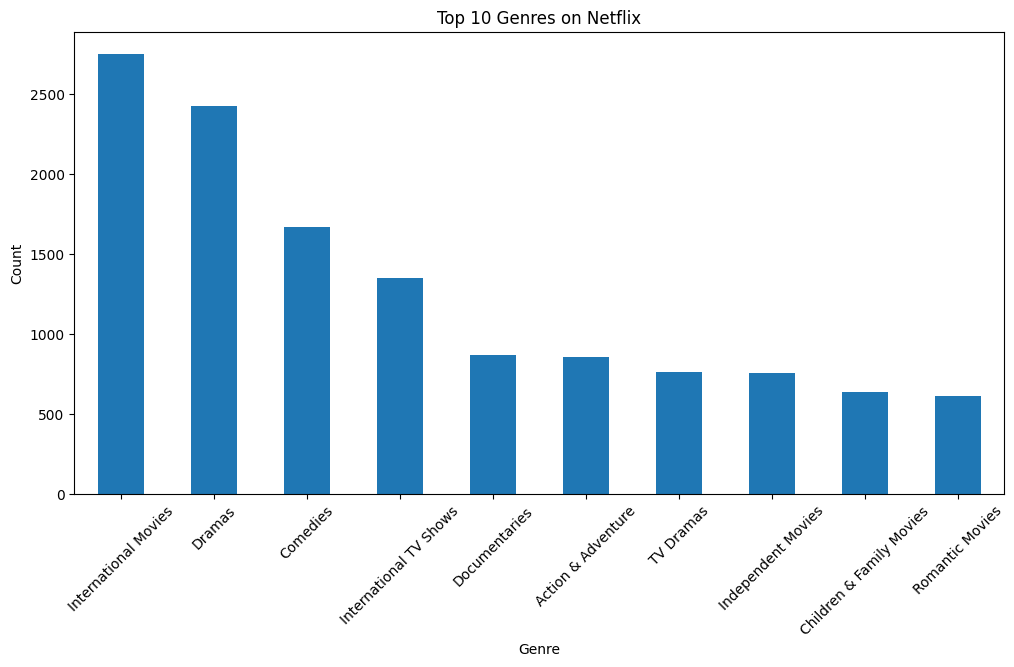

In [18]:
#5. Top genres
genres = df['listed_in'].str.split(', ').explode()

plt.figure(figsize=(12,6))

genres.value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()

In [19]:
print("Total Records:", df.shape[0])

Total Records: 8807


In [20]:
print("Total Columns:", df.shape[1])

Total Columns: 13


In [21]:
print(df['type'].value_counts())

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [22]:
print(df['country'].value_counts().head())

country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
Name: count, dtype: int64


In [23]:
print(df['rating'].value_counts().head())

rating
TV-MA    3211
TV-14    2160
TV-PG     863
R         799
PG-13     490
Name: count, dtype: int64


In [24]:
genres = df['listed_in'].str.split(', ').explode()
print(genres.value_counts().head())

listed_in
International Movies      2752
Dramas                    2427
Comedies                  1674
International TV Shows    1351
Documentaries              869
Name: count, dtype: int64


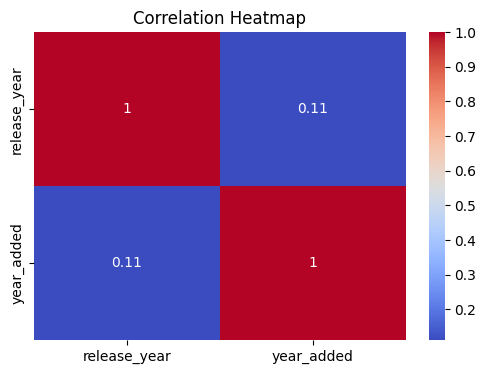

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(6,4))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

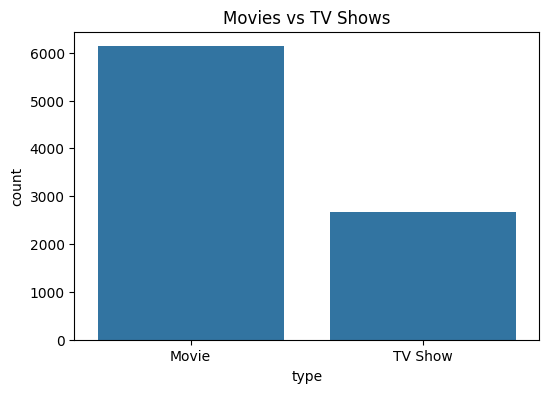

In [26]:
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df)

plt.title('Movies vs TV Shows')

plt.savefig('movies_vs_tvshows.png')

plt.show()